In [1]:
import numpy as np
import pandas as pd
import tifffile as tiff
import os

#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import plotly.express as px
import plotly.graph_objs as go
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score

import umap

2024-09-24 10:57:17.760760: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2024-09-24 10:57:17.760797: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


## Data load and preprocessing

In [2]:
# Load data files
nuclei = pd.read_csv('/app/data/50z/watershed_nuclei.txt', sep='\t', index_col = 1)
cytoplasm = pd.read_csv('/app/data/50z/filtered_segmented_cytoplasm.txt', sep='\t', index_col = 1)

In [3]:
display(nuclei)

,ImageNumber,AreaShape_BoundingBoxMaximum_X,AreaShape_BoundingBoxMaximum_Y,AreaShape_BoundingBoxMaximum_Z,AreaShape_BoundingBoxMinimum_X,AreaShape_BoundingBoxMinimum_Y,AreaShape_BoundingBoxMinimum_Z,AreaShape_BoundingBoxVolume,AreaShape_Center_X,AreaShape_Center_Y,AreaShape_Center_Z,AreaShape_EquivalentDiameter,AreaShape_EulerNumber,AreaShape_Extent,AreaShape_MajorAxisLength,AreaShape_MinorAxisLength,AreaShape_SurfaceArea,AreaShape_Volume,Children_filtered_segmented_cytoplasm_Count,Location_Center_X,Location_Center_Y,Location_Center_Z,Number_Object_Number
ObjectNumber,,,,,,,,,,,,,,,,,,,,,,,
1,1,50,47,10,0,7,0,20000,24.980656,26.431876,2.656434,20.864809,1,0.237800,56.055428,30.763629,2378.519775,4756,3,24.980656,26.431876,2.656434,1
2,1,178,52,7,159,25,0,3591,170.407186,41.447106,2.748503,9.854011,1,0.139515,24.195144,11.484614,551.945190,501,1,170.407186,41.447106,2.748503,2
3,1,197,93,7,160,59,0,8806,178.287213,76.262079,3.503904,19.854446,1,0.465365,45.407912,29.981938,2426.195801,4098,0,178.287213,76.262079,3.503904,3
4,1,80,81,1,73,66,0,105,76.142857,73.178571,0.000000,3.767499,1,0.266667,18.478338,3.102063,62.936607,28,0,76.142857,73.178571,0.000000,4
5,1,100,98,1,81,76,0,418,91.170732,86.847561,0.000000,6.791230,0,0.392344,27.857492,8.428254,226.559509,164,1,91.170732,86.847561,0.000000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1322,1,3561,2734,51,3547,2724,50,140,3554.243902,2728.268293,50.000000,4.278207,1,0.292857,18.272835,4.264976,78.361404,41,0,3554.243902,2728.268293,50.000000,1322
1323,1,3527,2742,51,3521,2737,50,30,3523.900000,2738.850000,50.000000,3.367781,1,0.666667,7.712328,4.332274,36.534443,20,0,3523.900000,2738.850000,50.000000,1323
1324,1,3558,2749,51,3546,2739,50,120,3551.092308,2743.261538,50.000000,4.988518,1,0.541667,15.388307,8.178822,103.632751,65,0,3551.092308,2743.261538,50.000000,1324


In [4]:
nuclei_cytoplasm_raw = pd.merge(nuclei, cytoplasm, left_on = 'Children_filtered_segmented_cytoplasm_Count', right_on = 'ObjectNumber', suffixes = ('_nuclei', '_cytoplasm'))
display(nuclei_cytoplasm_raw)

,ImageNumber_nuclei,AreaShape_BoundingBoxMaximum_X_nuclei,AreaShape_BoundingBoxMaximum_Y_nuclei,AreaShape_BoundingBoxMaximum_Z_nuclei,AreaShape_BoundingBoxMinimum_X_nuclei,AreaShape_BoundingBoxMinimum_Y_nuclei,AreaShape_BoundingBoxMinimum_Z_nuclei,AreaShape_BoundingBoxVolume_nuclei,AreaShape_Center_X_nuclei,AreaShape_Center_Y_nuclei,AreaShape_Center_Z_nuclei,AreaShape_EquivalentDiameter_nuclei,AreaShape_EulerNumber_nuclei,AreaShape_Extent_nuclei,AreaShape_MajorAxisLength_nuclei,AreaShape_MinorAxisLength_nuclei,AreaShape_SurfaceArea_nuclei,AreaShape_Volume_nuclei,Children_filtered_segmented_cytoplasm_Count,Location_Center_X_nuclei,Location_Center_Y_nuclei,Location_Center_Z_nuclei,Number_Object_Number_nuclei,ImageNumber_cytoplasm,AreaShape_BoundingBoxMaximum_X_cytoplasm,AreaShape_BoundingBoxMaximum_Y_cytoplasm,AreaShape_BoundingBoxMaximum_Z_cytoplasm,AreaShape_BoundingBoxMinimum_X_cytoplasm,AreaShape_BoundingBoxMinimum_Y_cytoplasm,AreaShape_BoundingBoxMinimum_Z_cytoplasm,AreaShape_BoundingBoxVolume_cytoplasm,AreaShape_Center_X_cytoplasm,AreaShape_Center_Y_cytoplasm,AreaShape_Center_Z_cytoplasm,AreaShape_EquivalentDiameter_cytoplasm,AreaShape_EulerNumber_cytoplasm,AreaShape_Extent_cytoplasm,AreaShape_MajorAxisLength_cytoplasm,AreaShape_MinorAxisLength_cytoplasm,AreaShape_SurfaceArea_cytoplasm,AreaShape_Volume_cytoplasm,Location_Center_X_cytoplasm,Location_Center_Y_cytoplasm,Location_Center_Z_cytoplasm,Number_Object_Number_cytoplasm,Parent_segmented_cytoplasm,Parent_watershed_nuclei
0,1,50,47,10,0,7,0,20000,24.980656,26.431876,2.656434,20.864809,1,0.237800,56.055428,30.763629,2378.519775,4756,3,24.980656,26.431876,2.656434,1,1,81,24,31,46,0,0,26040,62.814020,7.088698,16.186218,25.208863,1,0.322120,38.962072,33.363867,2627.021973,8388,62.814020,7.088698,16.186218,3,3,390
1,1,1029,175,10,955,105,0,51800,991.584192,137.759107,3.385327,36.623772,-2,0.496544,91.292284,56.890864,5531.215820,25721,3,991.584192,137.759107,3.385327,6,1,81,24,31,46,0,0,26040,62.814020,7.088698,16.186218,25.208863,1,0.322120,38.962072,33.363867,2627.021973,8388,62.814020,7.088698,16.186218,3,3,390
2,1,1604,714,9,1575,657,0,14877,1589.668794,683.743618,2.631302,22.875826,1,0.421322,61.590878,24.093389,2029.309326,6268,3,1589.668794,683.743618,2.631302,20,1,81,24,31,46,0,0,26040,62.814020,7.088698,16.186218,25.208863,1,0.322120,38.962072,33.363867,2627.021973,8388,62.814020,7.088698,16.186218,3,3,390
3,1,1768,784,2,1738,746,0,2280,1752.357224,766.904437,0.258248,11.884933,1,0.385526,41.797691,23.291670,805.862793,879,3,1752.357224,766.904437,0.258248,26,1,81,24,31,46,0,0,26040,62.814020,7.088698,16.186218,25.208863,1,0.322120,38.962072,33.363867,2627.021973,8388,62.814020,7.088698,16.186218,3,3,390
4,1,1948,796,20,1883,718,0,101400,1915.550412,761.488688,11.512318,36.688208,1,0.255000,91.519652,46.487808,8665.966797,25857,3,1915.550412,761.488688,11.512318,27,1,81,24,31,46,0,0,26040,62.814020,7.088698,16.186218,25.208863,1,0.322120,38.962072,33.363867,2627.021973,8388,62.814020,7.088698,16.186218,3,3,390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
817,1,2141,1051,45,2093,996,30,39600,2123.368785,1025.408825,36.881548,28.395490,2,0.302727,62.850290,30.327029,4296.177246,11988,5,2123.368785,1025.408825,36.881548,959,1,139,11,21,106,0,0,7623,122.031628,3.071066,6.783288,16.974760,1,0.335957,33.166981,19.789951,908.429382,2561,122.031628,3.071066,6.783288,5,5,509
818,1,2284,1515,20,2244,1450,8,31200,2263.694087,1482.281109,13.606481,28.384432,0,0.383782,66.970506,34.944113,5077.582031,11974,7,2263.694087,1482.281109,13.606481,496,1,90,44,20,61,11,0,19140,74.814010,25.415894,5.539432,23.250435,0,0.343835,40.759769,29.220074,2311.372070,6581,74.814010,25.415894,5.539432,7,13,390
819,1,3739,2057,39,3667,2013,15,76032,3698.623325,2034.984232,26.424034,32.369188,0,0.233560,65.020111,38.728195,6996.490234,17758,6,3698.623325

In [5]:
# Merge files
nuclei_cytoplasm = pd.merge(nuclei, cytoplasm, left_on = 'Children_filtered_segmented_cytoplasm_Count', right_on = 'ObjectNumber', suffixes = ('_nuclei', '_cytoplasm'))

# Delete coordinates features
columns_to_drop = [col for col in nuclei_cytoplasm.columns if 'X' in col or 'Y' in col or 'Z' in col]
nuclei_cytoplasm = nuclei_cytoplasm.drop(columns=columns_to_drop)

# Delete IDs and other useless stuff
nuclei_cytoplasm = nuclei_cytoplasm.drop(columns=['Children_filtered_segmented_cytoplasm_Count', 'Parent_segmented_cytoplasm', 'Parent_watershed_nuclei', 'ImageNumber_nuclei', 'Number_Object_Number_nuclei', 'ImageNumber_cytoplasm', 'Number_Object_Number_cytoplasm'])

In [6]:
display(nuclei_cytoplasm)

,AreaShape_BoundingBoxVolume_nuclei,AreaShape_EquivalentDiameter_nuclei,AreaShape_EulerNumber_nuclei,AreaShape_Extent_nuclei,AreaShape_MajorAxisLength_nuclei,AreaShape_MinorAxisLength_nuclei,AreaShape_SurfaceArea_nuclei,AreaShape_Volume_nuclei,AreaShape_BoundingBoxVolume_cytoplasm,AreaShape_EquivalentDiameter_cytoplasm,AreaShape_EulerNumber_cytoplasm,AreaShape_Extent_cytoplasm,AreaShape_MajorAxisLength_cytoplasm,AreaShape_MinorAxisLength_cytoplasm,AreaShape_SurfaceArea_cytoplasm,AreaShape_Volume_cytoplasm
0,20000,20.864809,1,0.237800,56.055428,30.763629,2378.519775,4756,26040,25.208863,1,0.322120,38.962072,33.363867,2627.021973,8388
1,51800,36.623772,-2,0.496544,91.292284,56.890864,5531.215820,25721,26040,25.208863,1,0.322120,38.962072,33.363867,2627.021973,8388
2,14877,22.875826,1,0.421322,61.590878,24.093389,2029.309326,6268,26040,25.208863,1,0.322120,38.962072,33.363867,2627.021973,8388
3,2280,11.884933,1,0.385526,41.797691,23.291670,805.862793,879,26040,25.208863,1,0.322120,38.962072,33.363867,2627.021973,8388
4,101400,36.688208,1,0.255000,91.519652,46.487808,8665.966797,25857,26040,25.208863,1,0.322120,38.962072,33.363867,2627.021973,8388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
817,39600,28.395490,2,0.302727,62.850290,30.327029,4296.177246,11988,7623,16.974760,1,0.335957,33.166981,19.789951,908.429382,2561
818,31200,28.384432,0,0.383782,66.970506,34.944113,5077.582031,11974,19140,23.250435,0,0.343835,40.759769,29.220074,2311.372070,6581
819,76032,32.369188,0,0.233560,65.020111,38.728195,6996.490234,17758,197847,43.671270,-5,0.220423,95.375615,51.567098,12600.503906,43610
820,62424,35.569967,1,0.377483,75.434417,42.684083,6759.525391,23564,197847,43.671270,-5,0.220423,95.375615,51.567098,12600.503906,43610


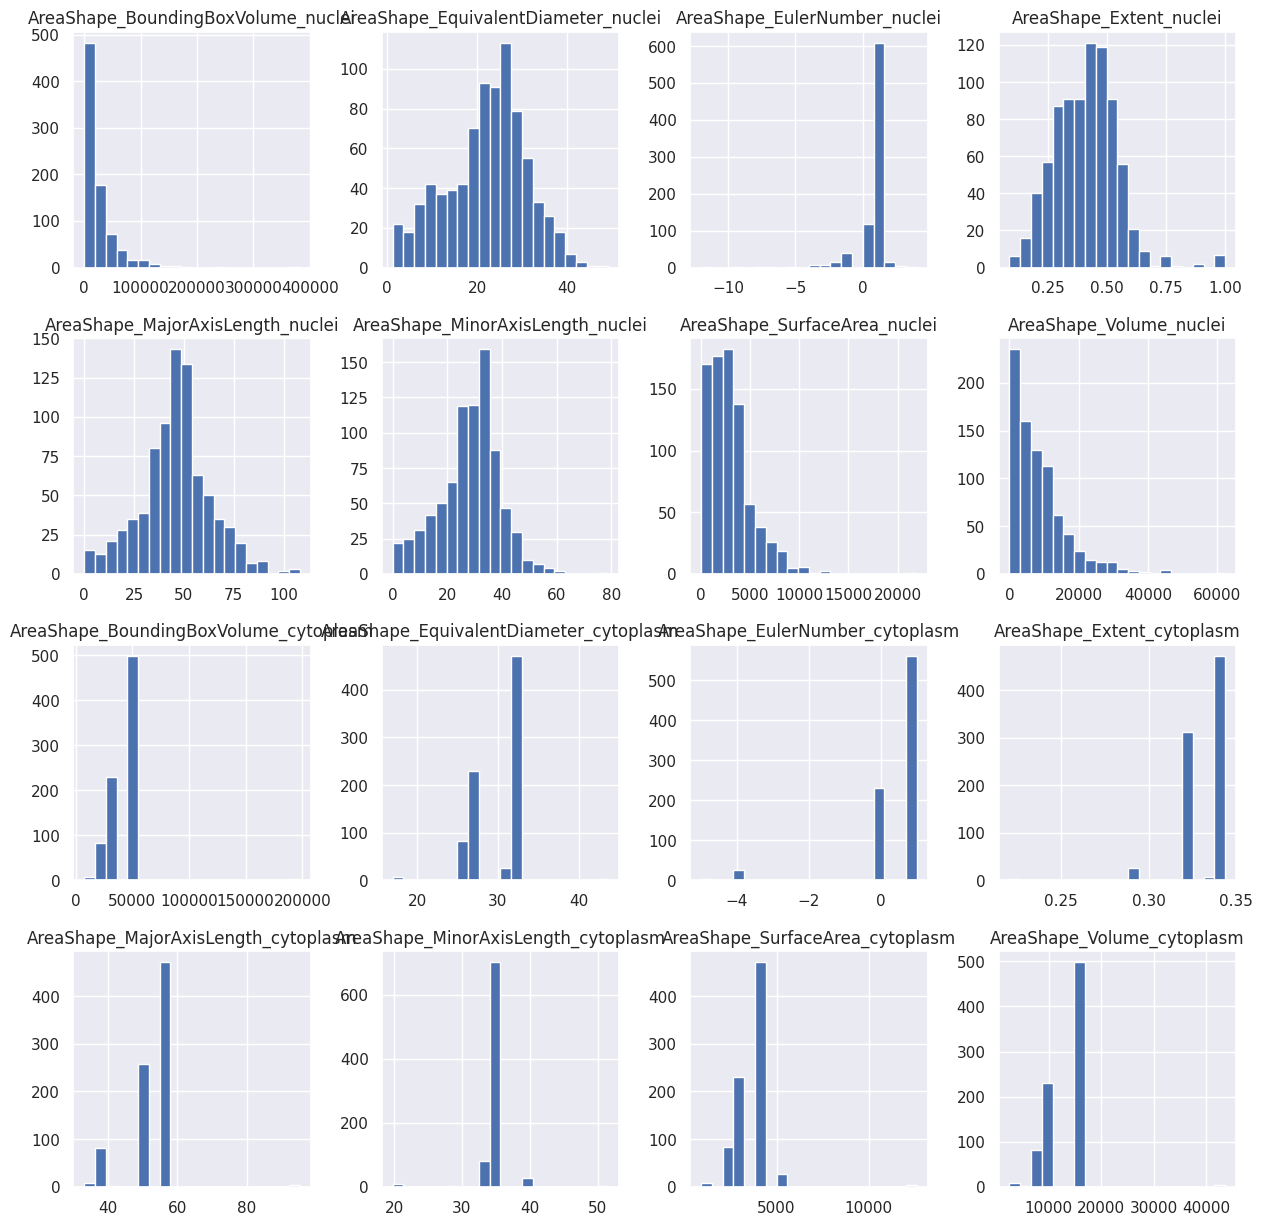

In [7]:
nuclei_cytoplasm.hist(bins=20, figsize=(15, 15))
plt.show()

## Pre-analysis

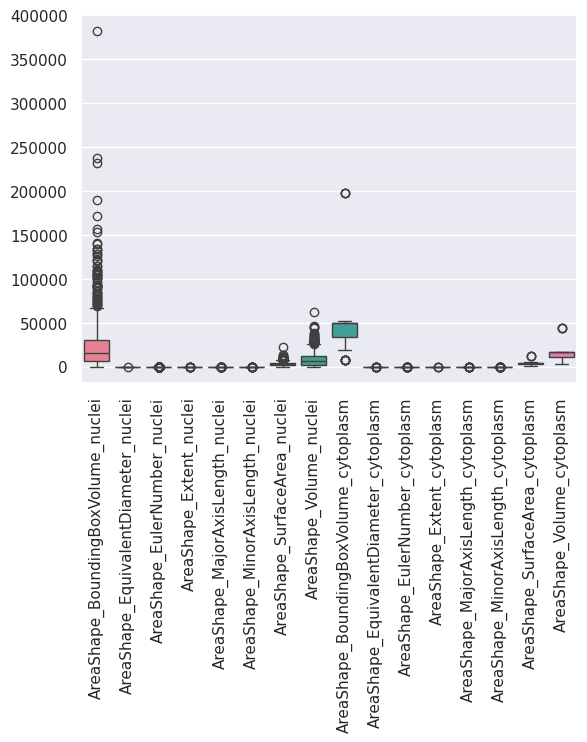

In [8]:
plt.figure()
sns.boxplot(data=nuclei_cytoplasm)
plt.xticks(rotation=90)
plt.show()

Mucho outlier. Valoramos una limpieza

In [9]:
Q1 = nuclei_cytoplasm.quantile(0.25)
Q3 = nuclei_cytoplasm.quantile(0.75)
IQR = Q3 - Q1

outliers = (nuclei_cytoplasm < (Q1 - 1.5 * IQR)) | (nuclei_cytoplasm > (Q3 + 1.5 * IQR))

outliers_detected = nuclei_cytoplasm[outliers.any(axis=1)]

In [10]:
nuclei_cytoplasm_cleaned = nuclei_cytoplasm[~outliers.any(axis=1)]
print(nuclei_cytoplasm_cleaned.shape)  # Ver cuántas filas quedaron

(538, 16)


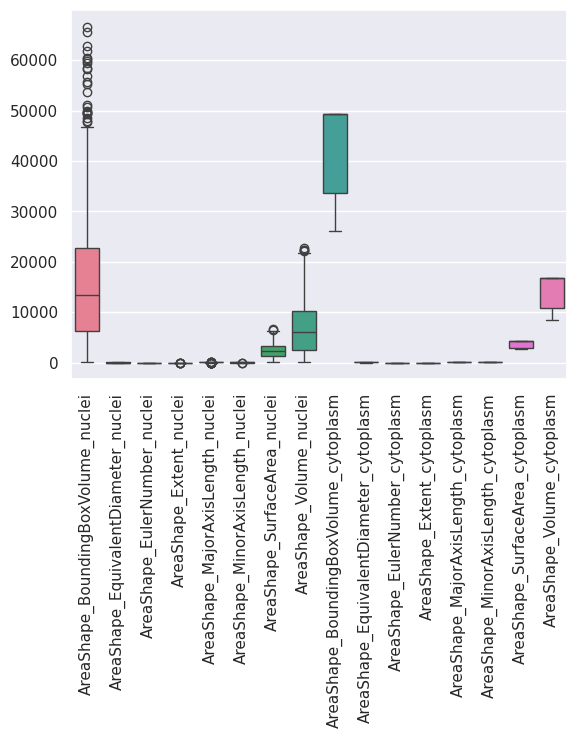

In [11]:
plt.figure()
sns.boxplot(data=nuclei_cytoplasm_cleaned)
plt.xticks(rotation=90)
plt.show()

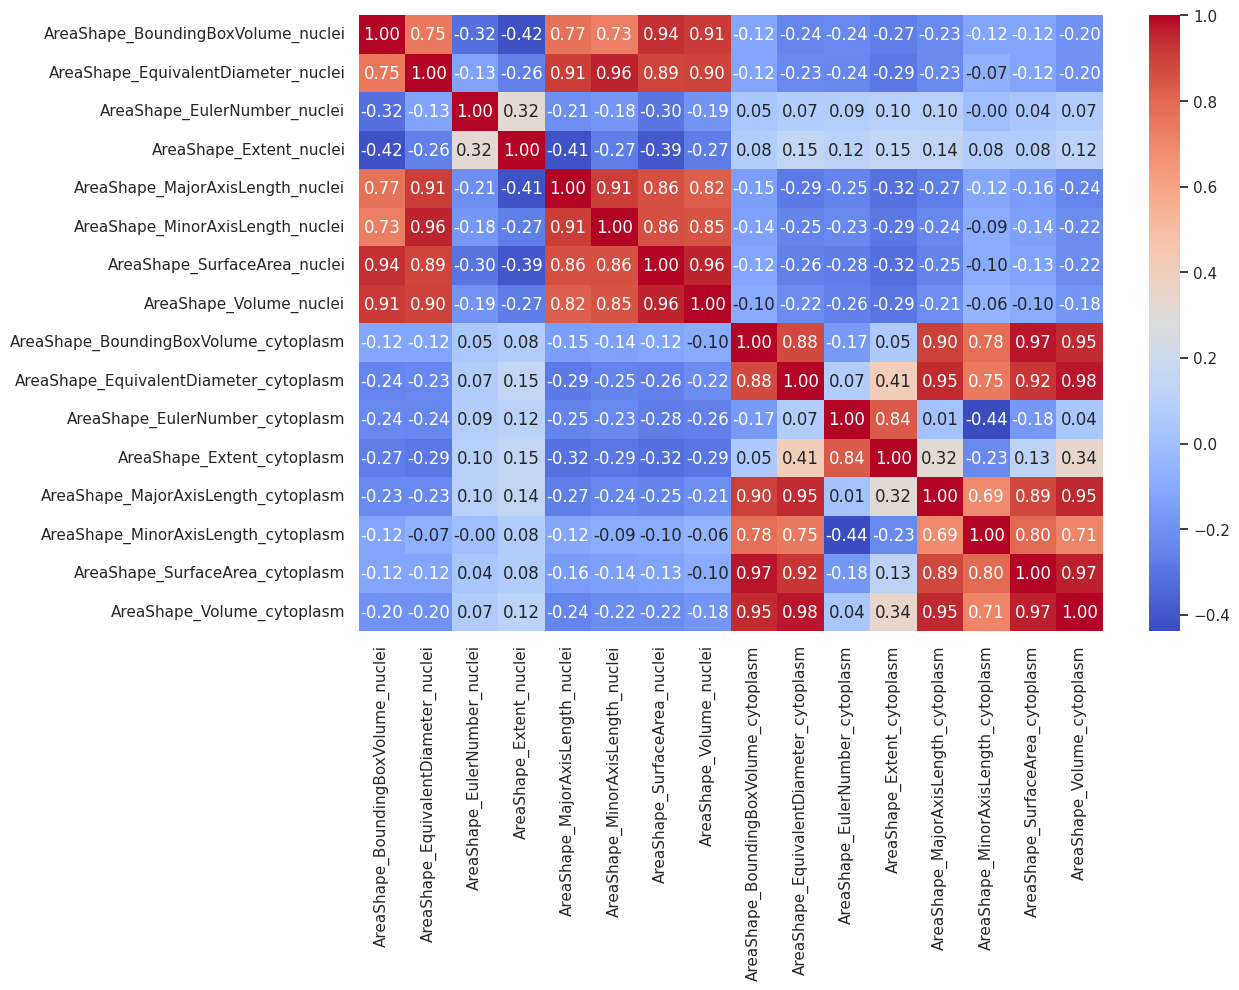

In [12]:
# Calcular la correlación entre características
corr_matrix = nuclei_cytoplasm.corr()

# Heatmap de la matriz de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

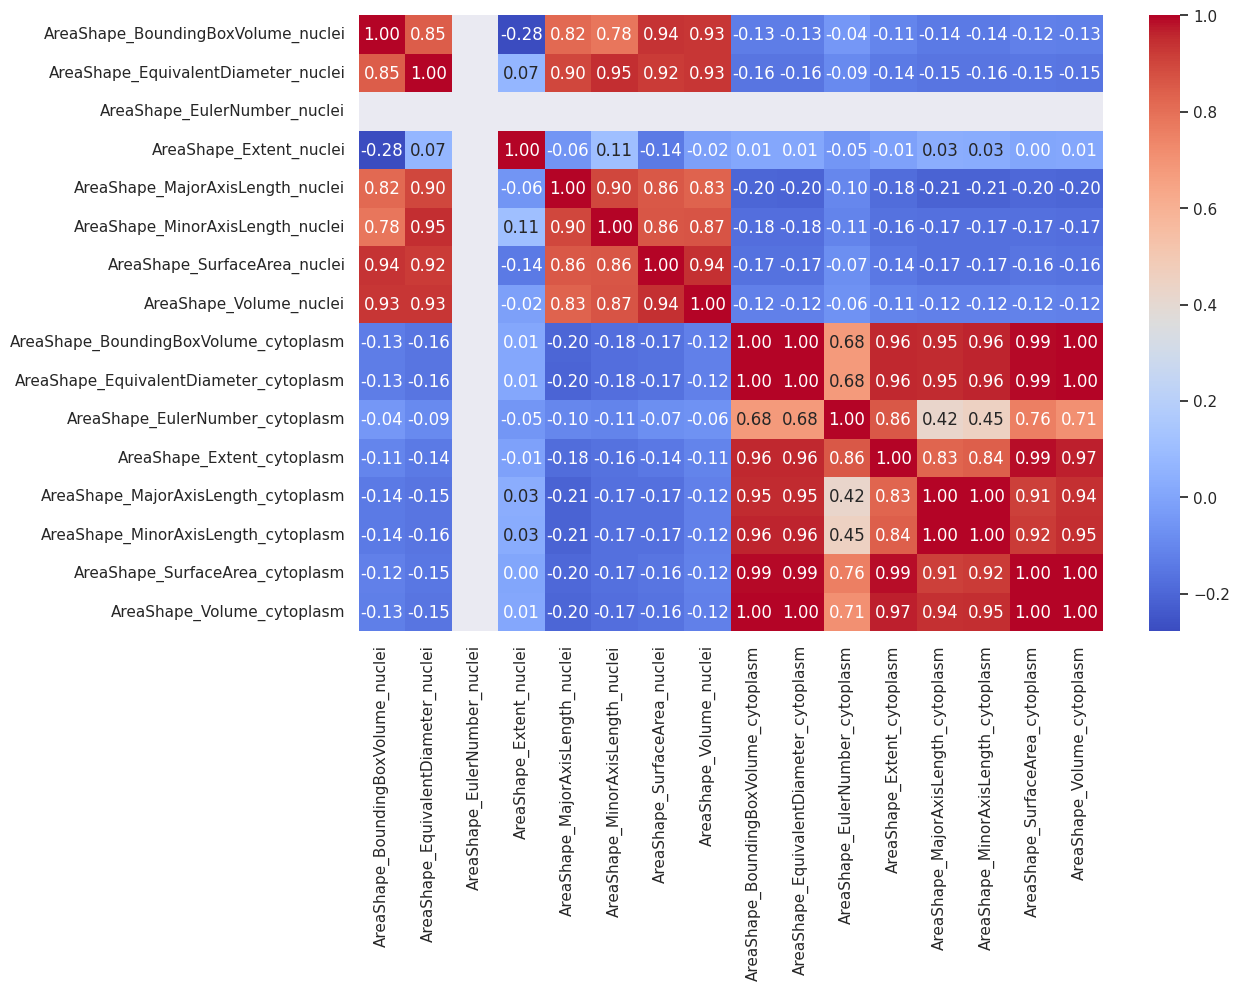

In [13]:
# Calcular la correlación entre características
corr_matrix = nuclei_cytoplasm_cleaned.corr()

# Heatmap de la matriz de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

No empleo los datos con limpieza de outliers porque hace que pierda variabilidad entre las celulas

## Standarization

In [14]:
# Standardize the data
scaler = StandardScaler()
nuclei_cytoplasm_std = scaler.fit_transform(nuclei_cytoplasm)

## PCA

In [15]:
# Perform PCA
pca = PCA()
pca.fit(nuclei_cytoplasm_std)

PCA()

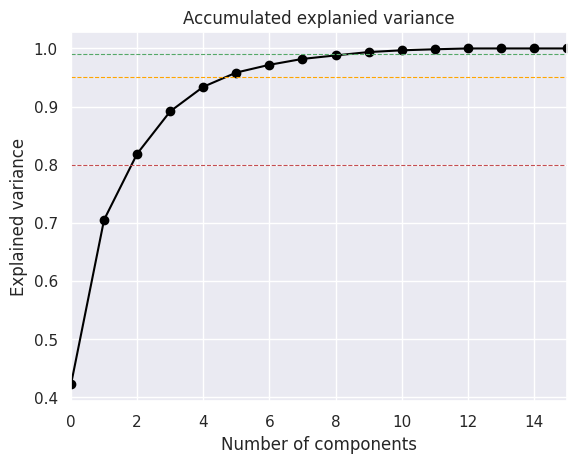

In [16]:
# Explained variance
pca.explained_variance_ratio_

plt.figure()

plt.plot(pca.explained_variance_ratio_.cumsum(), marker = 'o', color='black')
plt.xlabel('Number of components')
plt.ylabel('Explained variance')
plt.axhline(y=0.99, color='g', linestyle='--', linewidth=0.8, label='y = 0.99')
plt.axhline(y=0.95, color='orange', linestyle='--', linewidth=0.8, label='y = 0.8')
plt.axhline(y=0.8, color='r', linestyle='--', linewidth=0.8, label='y = 0.8')
plt.xlim(0, 15)

plt.title('Accumulated explanied variance')

plt.savefig('/app/html/1-explained_variance.svg', format='svg')

plt.show()

In [17]:
pca = PCA(n_components = 2)

In [18]:
pca.fit(nuclei_cytoplasm_std)

PCA(n_components=2)

In [19]:
pca_result = pca.transform(nuclei_cytoplasm_std)
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])

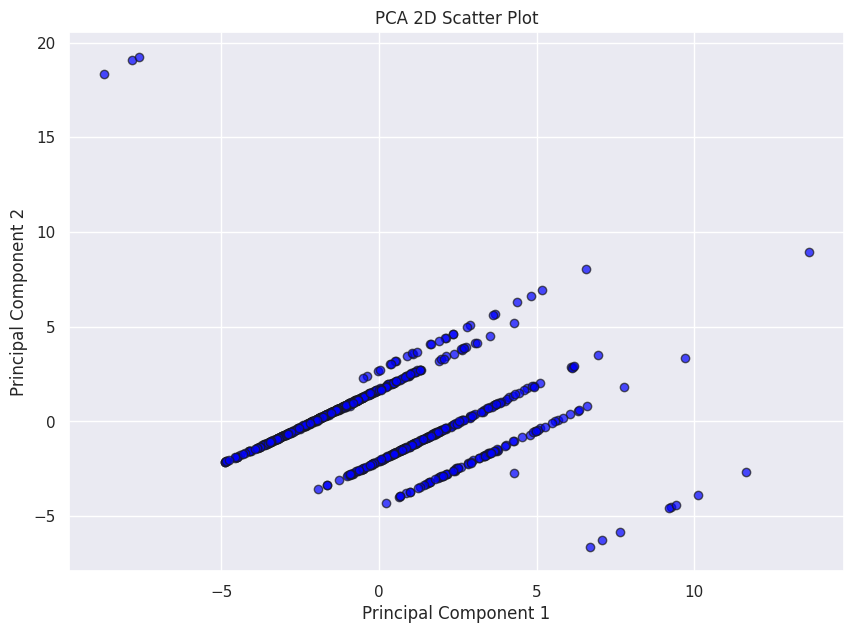

In [20]:
# 2D plot
plt.figure(figsize=(10, 7))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c='blue', edgecolor='k', alpha=0.7)
plt.title('PCA 2D Scatter Plot')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

plt.savefig('/app/html/2-pca.svg', format='svg')

plt.show()

### K-Means

In [21]:
scores_pca = pca.transform(nuclei_cytoplasm_std)

In [22]:
wcss = []
for i in range (1,21):
    kmeans_pca = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans_pca.fit(scores_pca)
    wcss.append(kmeans_pca.inertia_)

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explic

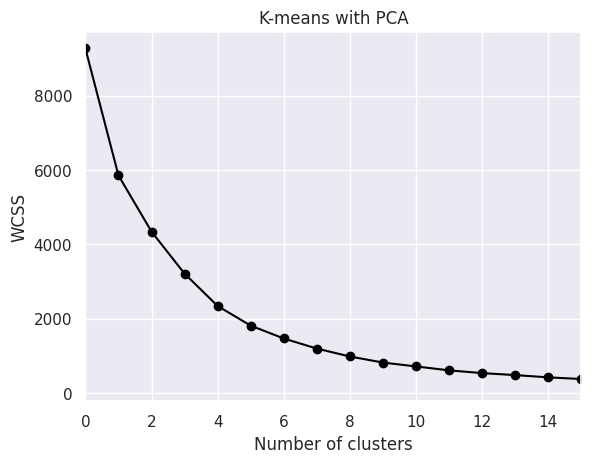

In [23]:
plt.figure()

plt.plot(wcss, marker = 'o', color='black')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('K-means with PCA')

plt.xlim(0, 15)

plt.savefig('/app/html/3-kmeans_pca.svg', format='svg')

plt.show()

In [24]:
kmeans_pca = KMeans(n_clusters = 2, init = 'k-means++', random_state = 42)

In [25]:
kmeans_pca.fit(scores_pca)

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=2, random_state=42)

In [26]:
df_segm_pca_kmeans = pd.concat([nuclei_cytoplasm.reset_index(drop = True), pd.DataFrame(scores_pca)], axis = 1)
df_segm_pca_kmeans.columns.values[-2: ] = ['C1', 'C2']
df_segm_pca_kmeans['Segment K-means PCA'] = kmeans_pca.labels_

In [27]:
df_segm_pca_kmeans['Segment'] = df_segm_pca_kmeans['Segment K-means PCA'].map({
    0:'Primero',
    1:'Segundo'})

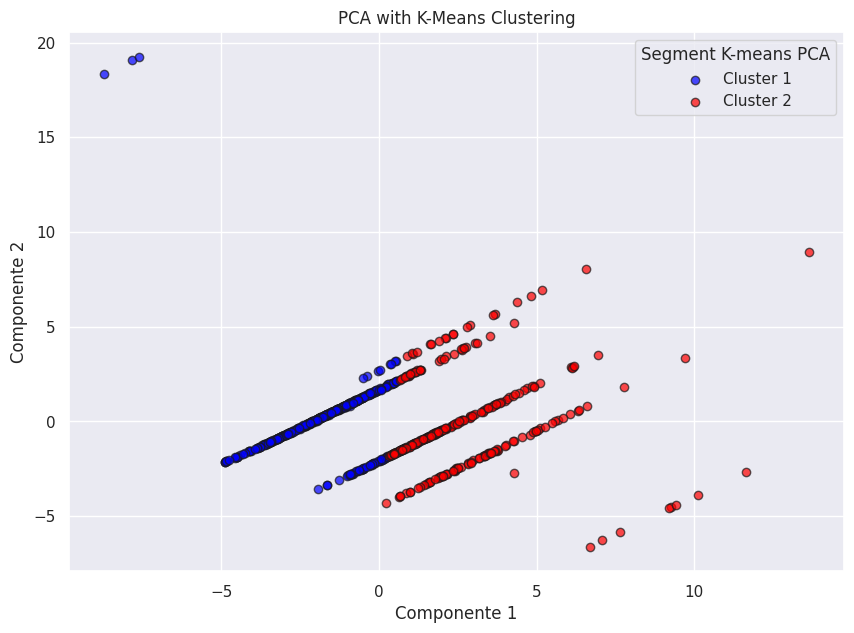

In [28]:
# Suponiendo que 'df_segm_pca_kmeans' es tu DataFrame con las componentes PCA y los clusters
df_plotly = df_segm_pca_kmeans.copy()
df_plotly['Segment K-means PCA'] = df_plotly['Segment K-means PCA'].map({
    0: 'Cluster 1',
    1: 'Cluster 2'
})

# Crear el gráfico 2D
plt.figure(figsize=(10, 7))
for cluster, color in {'Cluster 1': 'blue', 'Cluster 2': 'red'}.items():
    subset = df_plotly[df_plotly['Segment K-means PCA'] == cluster]
    plt.scatter(subset['C1'], subset['C2'], label=cluster, color=color, edgecolor='k', alpha=0.7)

plt.title('PCA with K-Means Clustering')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.legend(title='Segment K-means PCA')
plt.grid(True)

# Guardar el gráfico en un archivo SVG
plt.savefig('/app/html/4-pca_kmeans.svg', format='svg')

# Mostrar el gráfico (opcional)
plt.show()

df_plotly = df_segm_pca_kmeans.copy()
df_plotly['Segment K-means PCA'] = df_plotly['Segment K-means PCA'].map({
    0: 'Cluster 1',
    1: 'Cluster 2'
})
fig = px.scatter_3d(df_plotly, x='C1', y='C2', color='Segment K-means PCA',
                    labels={'C1': 'Componente 1', 'C2': 'Componente 2'},
                    title='PCA with K-Means Clustering')

fig.write_html('/app/html/4-pca_kmeans.html')

## UMap

In [29]:
n_neighbors = 20
min_dist = 0.1
n_components = 2
local_connectivity = 1
spread = 1
random_state = 42

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    n_components=2,
    local_connectivity=0.1,
    spread=1,
    random_state=42
)

# Ajustar el modelo y transformar los datos
umap_result = umap_model.fit_transform(nuclei_cytoplasm_std)

df_umap = pd.DataFrame(umap_result, columns=['UMAP1', 'UMAP2'])

/usr/local/lib/python3.8/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


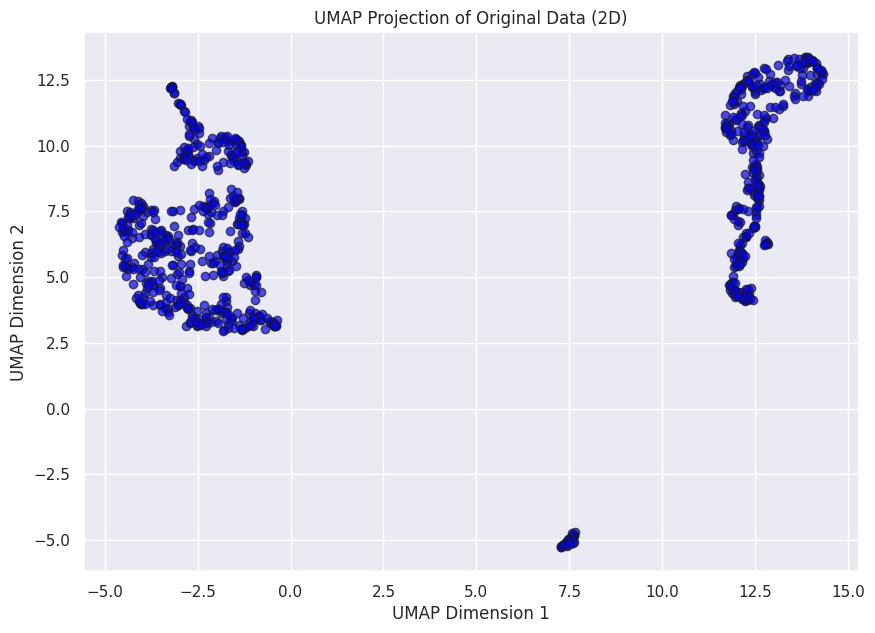

In [30]:
plt.figure(figsize=(10, 7))
plt.scatter(df_umap['UMAP1'], df_umap['UMAP2'], c='blue', edgecolor='k', alpha=0.7)
plt.title('UMAP Projection of Original Data (2D)')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.grid(True)

plt.savefig('/app/html/5-umap_2d.svg', format='svg')

plt.show()

In [31]:
# Realizar clustering con K-means para obtener etiquetas
kmeans = KMeans(n_clusters=3, random_state=random_state)  # Ajusta el número de clústeres según tu caso
labels = kmeans.fit_predict(umap_result)

# Calcular el Silhouette Score
silhouette_avg = silhouette_score(umap_result, labels)
print(silhouette_avg)

0.7718774


/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [32]:
umap_model_3d = umap.UMAP(n_neighbors=5, min_dist=min_dist, metric='euclidean', n_components=n_components, local_connectivity=local_connectivity, spread=spread, random_state=random_state)
umap_result_3d = umap_model_3d.fit_transform(nuclei_cytoplasm_std)
df_umap_3d = pd.DataFrame(umap_result_3d, columns=['UMAP1', 'UMAP2'])

fig_3d = px.scatter_3d(df_umap_3d, x='UMAP1', y='UMAP2',
                      labels={'UMAP1': 'UMAP Dimension 1', 'UMAP2': 'UMAP Dimension 2'},
                      title='UMAP Projection of Original Data (3D)')

fig_3d.write_html('/app/html/5-umap_3d.html')

/usr/local/lib/python3.8/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


### K-means

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will chang

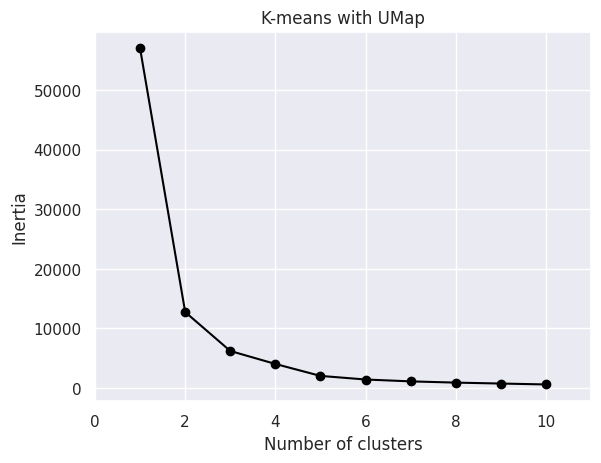

In [33]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(umap_result)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker = 'o', color='black')

plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('K-means with UMap')

plt.xlim(0, 11)

plt.savefig('/app/html/6-kmeans_umap.svg', format='svg')

plt.show()

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



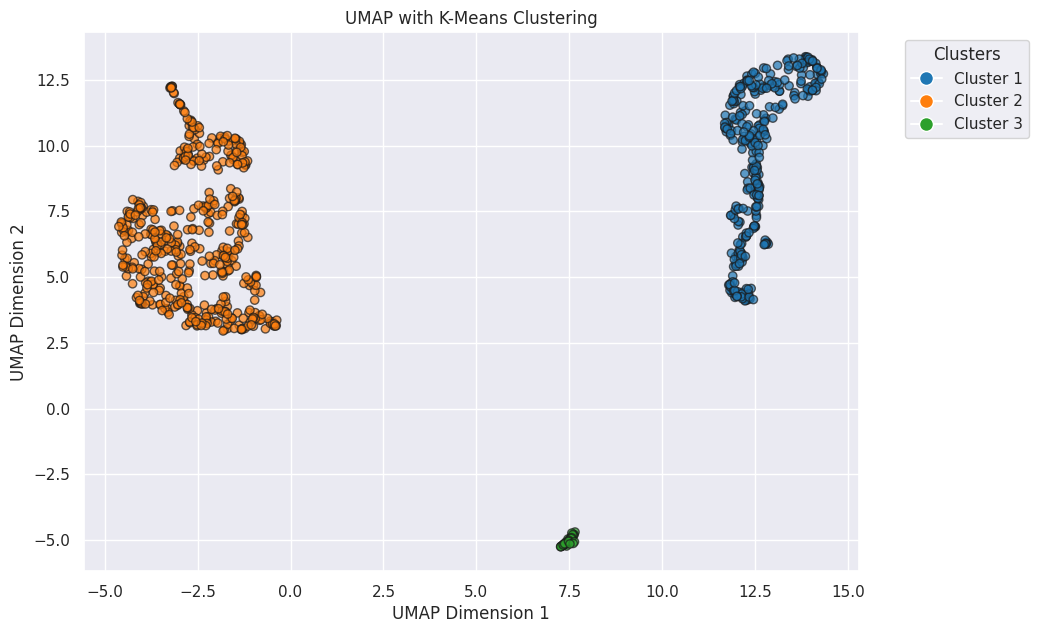

In [34]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(umap_result)
labels = kmeans.fit_predict(umap_result)

# Crear DataFrame con resultados de UMAP y etiquetas de clúster
df_umap = pd.DataFrame(umap_result, columns=['UMAP1', 'UMAP2'])
df_umap['Cluster'] = clusters

# Definir colores específicos para cada clúster
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Puedes elegir los colores que prefieras
cluster_names = ['Cluster 1', 'Cluster 2', 'Cluster 3']  # Nombres para los clústeres

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df_umap['UMAP1'], 
    df_umap['UMAP2'], 
    c=df_umap['Cluster'], 
    cmap=plt.matplotlib.colors.ListedColormap(colors),  # Usar el colormap discreto definido
    edgecolor='k', 
    alpha=0.7
)

# Añadir leyenda con nombres de clústeres
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=name) 
           for color, name in zip(colors, cluster_names)]
plt.legend(handles=handles, title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('UMAP with K-Means Clustering')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.grid(True)

plt.savefig('/app/html/7-umap_kmeans.svg', format='svg')
plt.show()

### Heatmap

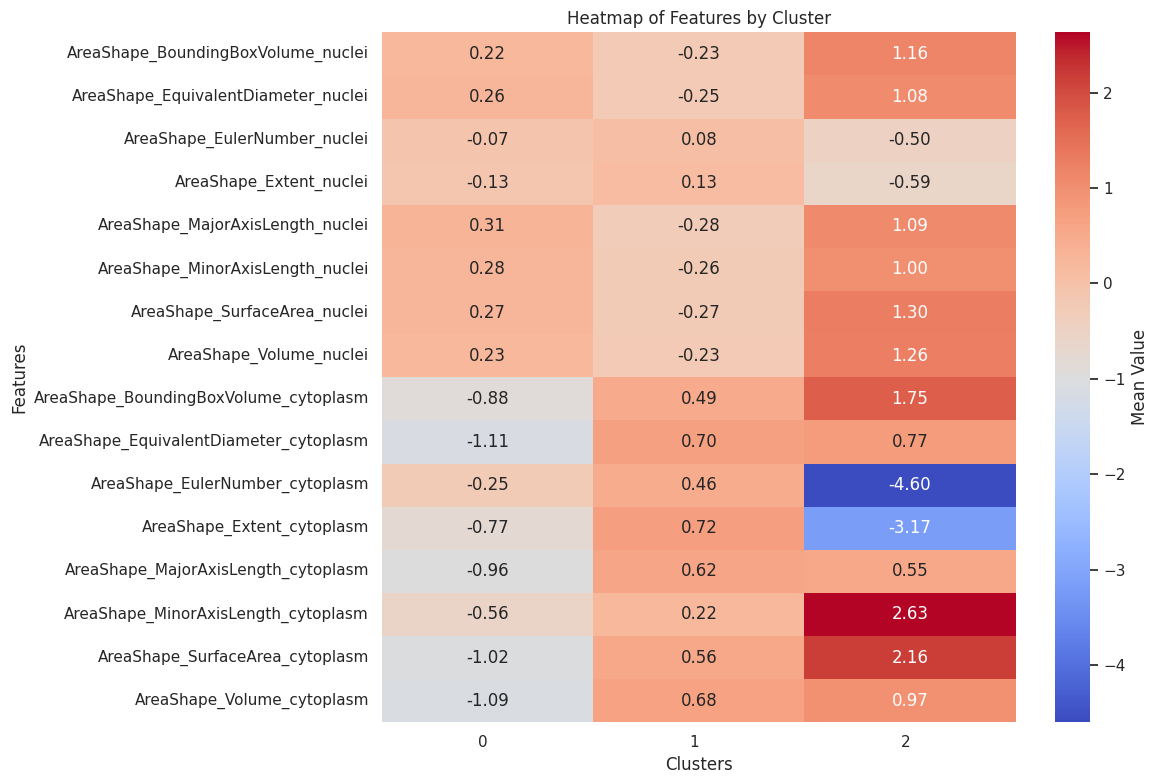

In [35]:
df_std_with_clusters = pd.concat([pd.DataFrame(nuclei_cytoplasm_std, columns=nuclei_cytoplasm.columns), df_umap['Cluster']], axis=1)

heatmap_data = df_std_with_clusters.groupby('Cluster').mean()

heatmap_data_transposed = heatmap_data.T

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_transposed, cmap='coolwarm', annot=True, fmt=".2f", cbar_kws={'label': 'Mean Value'})
plt.title('Heatmap of Features by Cluster')
plt.xlabel('Clusters')
plt.ylabel('Features')
plt.xticks(ha='right')
plt.tight_layout()

plt.savefig('/app/html/8-heatmap_features_by_cluster.svg', format='svg')

plt.show()

In [36]:
# Convertir nuclei_cytoplasm_std de nuevo a DataFrame para añadir la columna de clústeres
nuclei_cytoplasm_std_df = pd.DataFrame(nuclei_cytoplasm_raw, columns=nuclei_cytoplasm_raw.columns)

# Añadir la columna 'Cluster' con las etiquetas asignadas por K-means
nuclei_cytoplasm_std_df['Cluster'] = labels

# Verifica el resultado
display(nuclei_cytoplasm_std_df.head())

# Supongamos que tu DataFrame original se llama nuclei_cytoplasm_std_df

# 1. Reiniciar el índice para tener un conteo de filas
nuclei_cytoplasm_std_df = nuclei_cytoplasm_std_df.reset_index(drop=True)

# 2. Crear la columna 'objectnumber' con el número de filas
nuclei_cytoplasm_std_df['objectnumber'] = nuclei_cytoplasm_std_df.index + 1  # +1 para que empiece desde 1

# 3. Mover 'objectnumber' al principio
cols = ['objectnumber'] + [col for col in nuclei_cytoplasm_std_df.columns if col != 'objectnumber']
nuclei_cytoplasm_std_df = nuclei_cytoplasm_std_df[cols]

# 5. (Opcional) Exportar el DataFrame a un archivo CSV
nuclei_cytoplasm_std_df.to_csv('nuclei_with_objectnumber.csv', index=False)

,ImageNumber_nuclei,AreaShape_BoundingBoxMaximum_X_nuclei,AreaShape_BoundingBoxMaximum_Y_nuclei,AreaShape_BoundingBoxMaximum_Z_nuclei,AreaShape_BoundingBoxMinimum_X_nuclei,AreaShape_BoundingBoxMinimum_Y_nuclei,AreaShape_BoundingBoxMinimum_Z_nuclei,AreaShape_BoundingBoxVolume_nuclei,AreaShape_Center_X_nuclei,AreaShape_Center_Y_nuclei,AreaShape_Center_Z_nuclei,AreaShape_EquivalentDiameter_nuclei,AreaShape_EulerNumber_nuclei,AreaShape_Extent_nuclei,AreaShape_MajorAxisLength_nuclei,AreaShape_MinorAxisLength_nuclei,AreaShape_SurfaceArea_nuclei,AreaShape_Volume_nuclei,Children_filtered_segmented_cytoplasm_Count,Location_Center_X_nuclei,Location_Center_Y_nuclei,Location_Center_Z_nuclei,Number_Object_Number_nuclei,ImageNumber_cytoplasm,AreaShape_BoundingBoxMaximum_X_cytoplasm,AreaShape_BoundingBoxMaximum_Y_cytoplasm,AreaShape_BoundingBoxMaximum_Z_cytoplasm,AreaShape_BoundingBoxMinimum_X_cytoplasm,AreaShape_BoundingBoxMinimum_Y_cytoplasm,AreaShape_BoundingBoxMinimum_Z_cytoplasm,AreaShape_BoundingBoxVolume_cytoplasm,AreaShape_Center_X_cytoplasm,AreaShape_Center_Y_cytoplasm,AreaShape_Center_Z_cytoplasm,AreaShape_EquivalentDiameter_cytoplasm,AreaShape_EulerNumber_cytoplasm,AreaShape_Extent_cytoplasm,AreaShape_MajorAxisLength_cytoplasm,AreaShape_MinorAxisLength_cytoplasm,AreaShape_SurfaceArea_cytoplasm,AreaShape_Volume_cytoplasm,Location_Center_X_cytoplasm,Location_Center_Y_cytoplasm,Location_Center_Z_cytoplasm,Number_Object_Number_cytoplasm,Parent_segmented_cytoplasm,Parent_watershed_nuclei,Cluster
0,1,50,47,10,0,7,0,20000,24.980656,26.431876,2.656434,20.864809,1,0.237800,56.055428,30.763629,2378.519775,4756,3,24.980656,26.431876,2.656434,1,1,81,24,31,46,0,0,26040,62.81402,7.088698,16.186218,25.208863,1,0.32212,38.962072,33.363867,2627.021973,8388,62.81402,7.088698,16.186218,3,3,390,0
1,1,1029,175,10,955,105,0,51800,991.584192,137.759107,3.385327,36.623772,-2,0.496544,91.292284,56.890864,5531.215820,25721,3,991.584192,137.759107,3.385327,6,1,81,24,31,46,0,0,26040,62.81402,7.088698,16.186218,25.208863,1,0.32212,38.962072,33.363867,2627.021973,8388,62.81402,7.088698,16.186218,3,3,390,0
2,1,1604,714,9,1575,657,0,14877,1589.668794,683.743618,2.631302,22.875826,1,0.421322,61.590878,24.093389,2029.309326,6268,3,1589.668794,683.743618,2.631302,20,1,81,24,31,46,0,0,26040,62.81402,7.088698,16.186218,25.208863,1,0.32212,38.962072,33.363867,2627.021973,8388,62.81402,7.088698,16.186218,3,3,390,0
3,1,1768,784,2,1738,746,0,2280,1752.357224,766.904437,0.258248,11.884933,1,0.385526,41.797691,23.291670,805.862793,879,3,1752.357224,766.904437,0.258248,26,1,81,24,31,46,0,0,26040,62.81402,7.088698,16.186218,25.208863,1,0.32212,38.962072,33.363867,2627.021973,8388,62.81402,7.088698,16.186218,3,3,390,0
4,1,1948,796,20,1883,718,0,101400,1915.550412,761.488688,11.512318,36.688208,1,0.255000,91.519652,46.487808,8665.966797,25857,3,1915.550412,761.488688,11.512318,27,1,81,24,31,46,0,0,26040,62.81402,7.088698,16.186218,25.208863,1,0.32212,38.962072,33.363867,2627.021973,8388,62.81402,7.088698,16.186218,3,3,390,0


In [37]:


# 1. Reiniciar el índice para tener un conteo de filas
nuclei_cytoplasm_std_df = nuclei_cytoplasm_std_df.reset_index(drop=True)

# 2. Crear la columna 'objectnumber' con el número de filas
nuclei_cytoplasm_std_df['objectnumber'] = nuclei_cytoplasm_std_df.index + 1  # +1 para que empiece desde 1

cols = ['Cluster'] + [col for col in nuclei_cytoplasm_std_df.columns if col != 'Cluster']
nuclei_cytoplasm_std_df = nuclei_cytoplasm_std_df[cols]

# 3. Mover 'objectnumber' al principio
cols = ['objectnumber'] + [col for col in nuclei_cytoplasm_std_df.columns if col != 'objectnumber']
nuclei_cytoplasm_std_df = nuclei_cytoplasm_std_df[cols]



# Verifica el resultado
display(nuclei_cytoplasm_std_df)

nuclei_cytoplasm_std_df.to_csv('/app/html/9-clusters_per_cell.csv', index=False)

,objectnumber,Cluster,ImageNumber_nuclei,AreaShape_BoundingBoxMaximum_X_nuclei,AreaShape_BoundingBoxMaximum_Y_nuclei,AreaShape_BoundingBoxMaximum_Z_nuclei,AreaShape_BoundingBoxMinimum_X_nuclei,AreaShape_BoundingBoxMinimum_Y_nuclei,AreaShape_BoundingBoxMinimum_Z_nuclei,AreaShape_BoundingBoxVolume_nuclei,AreaShape_Center_X_nuclei,AreaShape_Center_Y_nuclei,AreaShape_Center_Z_nuclei,AreaShape_EquivalentDiameter_nuclei,AreaShape_EulerNumber_nuclei,AreaShape_Extent_nuclei,AreaShape_MajorAxisLength_nuclei,AreaShape_MinorAxisLength_nuclei,AreaShape_SurfaceArea_nuclei,AreaShape_Volume_nuclei,Children_filtered_segmented_cytoplasm_Count,Location_Center_X_nuclei,Location_Center_Y_nuclei,Location_Center_Z_nuclei,Number_Object_Number_nuclei,ImageNumber_cytoplasm,AreaShape_BoundingBoxMaximum_X_cytoplasm,AreaShape_BoundingBoxMaximum_Y_cytoplasm,AreaShape_BoundingBoxMaximum_Z_cytoplasm,AreaShape_BoundingBoxMinimum_X_cytoplasm,AreaShape_BoundingBoxMinimum_Y_cytoplasm,AreaShape_BoundingBoxMinimum_Z_cytoplasm,AreaShape_BoundingBoxVolume_cytoplasm,AreaShape_Center_X_cytoplasm,AreaShape_Center_Y_cytoplasm,AreaShape_Center_Z_cytoplasm,AreaShape_EquivalentDiameter_cytoplasm,AreaShape_EulerNumber_cytoplasm,AreaShape_Extent_cytoplasm,AreaShape_MajorAxisLength_cytoplasm,AreaShape_MinorAxisLength_cytoplasm,AreaShape_SurfaceArea_cytoplasm,AreaShape_Volume_cytoplasm,Location_Center_X_cytoplasm,Location_Center_Y_cytoplasm,Location_Center_Z_cytoplasm,Number_Object_Number_cytoplasm,Parent_segmented_cytoplasm,Parent_watershed_nuclei
0,1,0,1,50,47,10,0,7,0,20000,24.980656,26.431876,2.656434,20.864809,1,0.237800,56.055428,30.763629,2378.519775,4756,3,24.980656,26.431876,2.656434,1,1,81,24,31,46,0,0,26040,62.814020,7.088698,16.186218,25.208863,1,0.322120,38.962072,33.363867,2627.021973,8388,62.814020,7.088698,16.186218,3,3,390
1,2,0,1,1029,175,10,955,105,0,51800,991.584192,137.759107,3.385327,36.623772,-2,0.496544,91.292284,56.890864,5531.215820,25721,3,991.584192,137.759107,3.385327,6,1,81,24,31,46,0,0,26040,62.814020,7.088698,16.186218,25.208863,1,0.322120,38.962072,33.363867,2627.021973,8388,62.814020,7.088698,16.186218,3,3,390
2,3,0,1,1604,714,9,1575,657,0,14877,1589.668794,683.743618,2.631302,22.875826,1,0.421322,61.590878,24.093389,2029.309326,6268,3,1589.668794,683.743618,2.631302,20,1,81,24,31,46,0,0,26040,62.814020,7.088698,16.186218,25.208863,1,0.322120,38.962072,33.363867,2627.021973,8388,62.814020,7.088698,16.186218,3,3,390
3,4,0,1,1768,784,2,1738,746,0,2280,1752.357224,766.904437,0.258248,11.884933,1,0.385526,41.797691,23.291670,805.862793,879,3,1752.357224,766.904437,0.258248,26,1,81,24,31,46,0,0,26040,62.814020,7.088698,16.186218,25.208863,1,0.322120,38.962072,33.363867,2627.021973,8388,62.814020,7.088698,16.186218,3,3,390
4,5,0,1,1948,796,20,1883,718,0,101400,1915.550412,761.488688,11.512318,36.688208,1,0.255000,91.519652,46.487808,8665.966797,25857,3,1915.550412,761.488688,11.512318,27,1,81,24,31,46,0,0,26040,62.814020,7.088698,16.186218,25.208863,1,0.322120,38.962072,33.363867,2627.021973,8388,62.814020,7.088698,16.186218,3,3,390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
817,818,0,1,2141,1051,45,2093,996,30,39600,2123.368785,1025.408825,36.881548,28.395490,2,0.302727,62.850290,30.327029,4296.177246,11988,5,2123.368785,1025.408825,36.881548,959,1,139,11,21,106,0,0,7623,122.031628,3.071066,6.783288,16.974760,1,0.335957,33.166981,19.789951,908.429382,2561,122.031628,3.071066,6.783288,5,5,509
818,819,0,1,2284,1515,20,2244,1450,8,31200,2263.694087,1482.281109,13.606481,28.384432,0,0.383782,66.970506,34.944113,5077.582031,11974,7,2263.694087,1482.281109,13.606481,496,1,90,44,20,61,11,0,19140,74.814010,25.415894,5.539432,23.250435,0,0.343835,40.759769,29.220074,2311.372070,6581,74.814010,25.415894,5.539432,7,13,390
819,820,2,1,3739,2057,39,3667,2013,15,76032,3698.623325,2034.984232,26.424034,32.36

In [43]:
# Load the DataFrame
df = pd.read_csv('/app/html/9-clusters_per_cell.csv')
print(f"DataFrame loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

# Load the raw TIFF
tif_raw = tiff.imread('/app/data/original.tif')
print(f"TIFF image loaded with shape: {tif_raw.shape}.")

# Create a folder to save the resulting images
output_dir = '/app/html/cluster_images_color'
os.makedirs(output_dir, exist_ok=True)
print(f"Folder for saving images created at: {output_dir}")

# Define colors for each cluster
colors = {
    0: 'red',    # Red
    1: 'green',  # Green
    2: 'blue',   # Blue
}

# Create a figure for the legend
def create_legend():
    plt.figure(figsize=(5, 1))
    for cluster, color in colors.items():
        plt.scatter([], [], color=color, label=f'Cluster {cluster}')
    plt.legend(loc='center', ncol=4)
    plt.axis('off')
    legend_path = os.path.join(output_dir, 'legend.png')
    plt.savefig(legend_path, bbox_inches='tight', pad_inches=0)
    plt.close()
    return legend_path

legend_path = create_legend()  # Create and save the legend

# Iterate over each Z layer
for z in range(tif_raw.shape[0]):
    print(f"Processing layer Z={z}.")
    images_dict = np.copy(tif_raw[z])  # Copy the image of the current Z layer

    # Filter the cells that are in the current Z layer
    df_z = df[np.round(df['AreaShape_Center_Z_nuclei']).astype(int) == z]
    
    print(f"Found {df_z.shape[0]} cells in layer Z={z}.")  # Count the found cells

    for index, row in df_z.iterrows():
        x = int(row['AreaShape_Center_X_nuclei'])
        y = int(row['AreaShape_Center_Y_nuclei'])
        cluster = int(row['Cluster'])  # Convert to integer

        # Draw the cluster number on the accumulated image with a white outline
        if 0 <= x < images_dict.shape[1] and 0 <= y < images_dict.shape[0]:
            # Draw outline
            outline_color = 'white'
            plt.text(x-1, y-1, str(cluster), color=outline_color, fontsize=6, ha='center', va='center')  # Top-left
            plt.text(x+1, y-1, str(cluster), color=outline_color, fontsize=6, ha='center', va='center')  # Top-right
            plt.text(x-1, y+1, str(cluster), color=outline_color, fontsize=6, ha='center', va='center')  # Bottom-left
            plt.text(x+1, y+1, str(cluster), color=outline_color, fontsize=6, ha='center', va='center')  # Bottom-right
            
            # Draw main text
            plt.text(x, y, str(cluster), color=colors.get(cluster, 'white'), fontsize=6, ha='center', va='center')  # Main text

    # Show the accumulated image before saving
    plt.imshow(images_dict, cmap='gray')
    plt.axis('off')
    
    # Add the legend to the image
    legend_img = plt.imread(legend_path)
    plt.figimage(legend_img, 10, 10, alpha=1)  # Adjust coordinates as needed

    # Save the image with all cluster numbers
    output_image_path = os.path.join(output_dir, f'output_image_layer_{z + 1}.png')
    plt.savefig(output_image_path, bbox_inches='tight', pad_inches=0, dpi=300)
    print(f"Image saved as: {output_image_path}")

    plt.close()  # Close the figure to free memory

print("All processes completed.")

DataFrame loaded with 822 rows and 49 columns.
TIFF image loaded with shape: (51, 3788, 3788, 3).
Folder for saving images created at: /app/html/cluster_images_color
Processing layer Z=0.
Found 17 cells in layer Z=0.
Image saved as: /app/html/cluster_images_color/output_image_layer_1.png
Processing layer Z=1.
Found 18 cells in layer Z=1.
Image saved as: /app/html/cluster_images_color/output_image_layer_2.png
Processing layer Z=2.
Found 20 cells in layer Z=2.
Image saved as: /app/html/cluster_images_color/output_image_layer_3.png
Processing layer Z=3.
Found 30 cells in layer Z=3.
Image saved as: /app/html/cluster_images_color/output_image_layer_4.png
Processing layer Z=4.
Found 31 cells in layer Z=4.
Image saved as: /app/html/cluster_images_color/output_image_layer_5.png
Processing layer Z=5.
Found 26 cells in layer Z=5.
Image saved as: /app/html/cluster_images_color/output_image_layer_6.png
Processing layer Z=6.
Found 23 cells in layer Z=6.
Image saved as: /app/html/cluster_images_colo